# Scientific Validity of PPI for Binary Mean Estimation

This notebook provides empirical evidence that GLIDE's **Prediction-Powered Inference (PPI)** implementation is statistically valid.

**Setup:** We estimate the mean of a binary outcome (e.g., the pass rate of an LLM-as-a-judge evaluation). We have:
- A small set of **human labels** (`y_true`) — expensive but unbiased
- A large set of **LLM-as-judge proxy labels** (`y_proxy`) — cheap but potentially biased

PPI combines both to produce confidence intervals that are:
1. **Valid** — they cover the true mean at the specified rate (e.g. 90% confidence)
2. **Shorter** — as compared to those obtained with true labels only, especially when the proxy is strongly correlated with the truth

We test these two claims empirically across a range of proxy/human (true) correlation levels.

In [9]:
cd ../../

/Users/ibrahimmerad


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from glide.core.simulated import generate_dataset_binary
from glide.estimators import PPIMeanEstimator

## Experiment Parameters

We fix all parameters up front so every section of this notebook uses a consistent setup.

| Parameter | Value | Description |
|-----------|-------|-------------|
| `CONFIDENCE_LEVEL` | 0.9 | Confidence level → 90% confidence intervals |
| `N_TRUE` | 500 | Number of human-labeled samples |
| `N_PROXY` | 5000 | Number of proxy-only samples |
| `TRUE_MEAN` | 0.6 | Ground-truth population mean |
| `PROXY_MEAN` | 0.5 | Mean of the proxy labels (biased) |
| `N_SEEDS` | 500 | Number of Monte Carlo repetitions per condition |

> **Note on correlation bounds:** Depending on the values of TRUE_MEAN and PROXY_MEAN, extreme correlation values (close to 0 or 1) may not be possible. Correlation sweeps are kept within these limit.

In [14]:
CONFIDENCE_LEVEL = 0.9   # fixed throughout — 90% CI
N_TRUE = 500
N_PROXY = 5000
TRUE_MEAN = 0.55
PROXY_MEAN = 0.5
N_SEEDS = 500

METHODS = ['True only', 'True + Proxy', 'Proxy only', 'PPI']

## 1. Data Generation

We use `generate_dataset_binary` to simulate a realistic evaluation scenario.
It generates correlated binary labels `(y_true, y_proxy)` for `N_TRUE` items, plus `N_PROXY` items with only `y_proxy` available.

The `correlation` parameter controls the Pearson correlation between human and LLM-as-judge labels on the labeled subset.

In [ ]:
# Single example dataset for illustration
example_dataset = generate_dataset_binary(
    n=N_TRUE,
    N=N_PROXY,
    true_mean=TRUE_MEAN,
    proxy_mean=PROXY_MEAN,
    correlation=0.8,
    random_seed=42,
)

data_array = example_dataset.to_numpy(fields=["y_true", "y_proxy"])

Total records : 5500
Labeled rows  : 500  (y_true available)
Unlabeled rows: 5000   (proxy only)

Empirical correlation (labeled subset): 0.788  (target: 0.8)


## 2. Estimation Methods

We compare four estimators:

| Method | Data used | Notes |
|--------|-----------|-------|
| **True only** | `y_true` (n=500) | Classical CLT CI — the gold standard for validity |
| **True + Proxy** | `y_true` + `y_proxy` pooled | Ignores the bias of the proxy |
| **Proxy only** | `y_proxy` (N=5000) | Biased — cheap but wrong |
| **PPI** | `y_true` + `y_proxy` (corrected) | Our method — valid and efficient |

The helper below returns the mean and 90% CI for each method.

In [16]:
def dataset_to_vectors(dataset):
    """Split a Dataset into labeled and unlabeled numpy arrays."""
    arr = dataset.to_numpy(fields=["y_true", "y_proxy"])
    nan_mask = np.isnan(arr[:, 0])
    y_true = arr[~nan_mask, 0]
    y_proxy_labeled = arr[~nan_mask, 1]
    y_proxy_unlabeled = arr[nan_mask, 1]
    return y_true, y_proxy_labeled, y_proxy_unlabeled


def generate_estimates(dataset, confidence_level=CONFIDENCE_LEVEL):
    """Return mean and CI for all four methods."""
    # --- PPI ---
    ppi_estimator = PPIMeanEstimator()
    ppi_result = ppi_estimator.estimate(
        dataset,
        y_true_field="y_true",
        y_proxy_field="y_proxy",
        confidence_level=confidence_level,
    )
    ppi_mean = ppi_result.result.mean
    ppi_ci = (ppi_result.result.lower_bound, ppi_result.result.upper_bound)

    # --- Classical baselines ---
    y_true, y_proxy_lab, y_proxy_unlab = dataset_to_vectors(dataset)
    z = norm.ppf((1 + confidence_level) / 2)

    def classical_ci(data):
        mu = np.mean(data)
        se = np.std(data, ddof=1) / np.sqrt(len(data))
        return mu, (mu - z * se, mu + z * se)

    lo_mean, lo_ci = classical_ci(y_true)
    ls_mean, ls_ci = classical_ci(np.concatenate([y_true, y_proxy_unlab]))
    so_mean, so_ci = classical_ci(np.concatenate([y_proxy_lab, y_proxy_unlab]))

    return {
        'True only':         {"mean": lo_mean, "CI": lo_ci},
        'True + Proxy':  {"mean": ls_mean, "CI": ls_ci},
        'Proxy only':        {"mean": so_mean, "CI": so_ci},
        'PPI':                   {"mean": ppi_mean, "CI": ppi_ci},
    }

### Single-run comparison

Let's first visualize the estimates and their confidence intervals for a single dataset (correlation = 0.8).
The red dashed line marks the true mean.

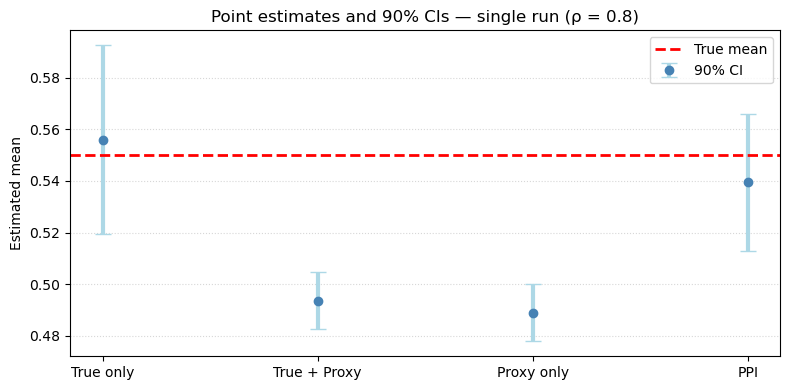

CI widths:
  True only                : 0.0732
  True + Proxy             : 0.0222
  Proxy only               : 0.0222
  PPI                      : 0.0531


In [17]:
results = generate_estimates(example_dataset)

means = [results[m]["mean"] for m in METHODS]
half_widths = [(results[m]["CI"][1] - results[m]["CI"][0]) / 2 for m in METHODS]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(METHODS, means, yerr=half_widths, fmt='o', color='steelblue',
            ecolor='lightblue', elinewidth=3, capsize=6, label='90% CI')
ax.axhline(y=TRUE_MEAN, color='red', linestyle='--', linewidth=2, label='True mean')
ax.set_ylabel('Estimated mean')
ax.set_title('Point estimates and 90% CIs — single run (ρ = 0.8)')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()
print("CI widths:")
for m in METHODS:
    w = results[m]["CI"][1] - results[m]["CI"][0]
    print(f"  {m:<25}: {w:.4f}")



## 3. Coverage Validity

A confidence interval at level **confidence_level** is **valid** if, over many repeated experiments, it contains the true parameter at least **confidence_level** of the time.

We check this empirically by repeating the experiment `N_SEEDS` times with different random seeds and counting how often each method's CI covers `TRUE_MEAN`.

> **Key question:** Does PPI maintain valid coverage, or does it sacrifice it for shorter intervals?

In [18]:
def simulate_coverages(correlation, n_seeds=N_SEEDS, confidence_level=CONFIDENCE_LEVEL):
    """Estimate coverage for each method over n_seeds Monte Carlo runs."""
    hits = {m: 0 for m in METHODS}
    for seed in range(n_seeds):
        ds = generate_dataset_binary(
            n=N_TRUE, N=N_PROXY,
            true_mean=TRUE_MEAN, proxy_mean=PROXY_MEAN,
            correlation=correlation, random_seed=seed,
        )
        est = generate_estimates(ds, confidence_level=confidence_level)
        for m in METHODS:
            lo, hi = est[m]["CI"]
            hits[m] += int(lo <= TRUE_MEAN <= hi)
    return {m: hits[m] / n_seeds for m in METHODS}

### Coverage vs confidence level — for three correlation levels

We sweep the confidence level from 0.55 to 0.95 and plot the observed coverage.
For a valid method, the dots should fall on or above the black diagonal $y = \text{confidence\_level}$.

We do this for **low** ($\rho = 0.15$), **medium** ($\rho = 0.50$), and **high** ($\rho = 0.85$) proxy correlation.

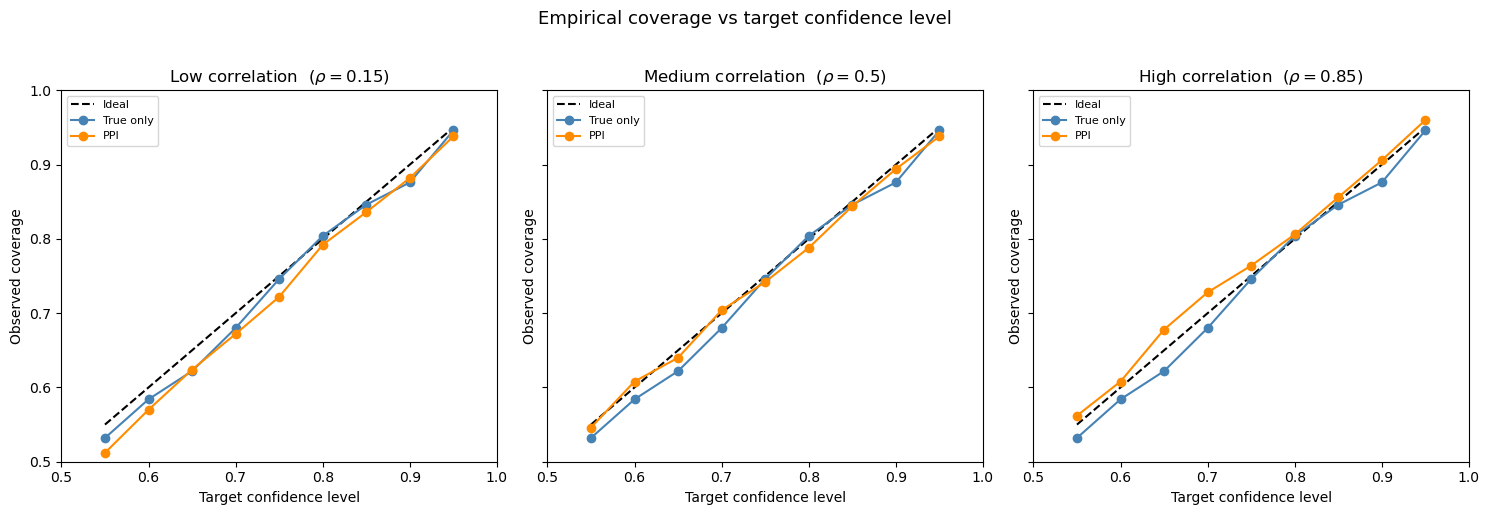

In [19]:
correlations_3 = [0.15, 0.50, 0.85]
corr_labels = ["Low", "Medium", "High"]
confidence_levels_sweep = np.arange(0.55, 1.00, 0.05)

# ---- run simulations ----
coverage_by_corr_cl = {}   # [corr][confidence_level] -> {method: coverage}
for rho in correlations_3:
    coverage_by_corr_cl[rho] = {}
    for cl in confidence_levels_sweep:
        coverage_by_corr_cl[rho][cl] = simulate_coverages(rho, confidence_level=cl)

# ---- plot ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
plot_methods = ['True only', 'PPI']
colors = {'True only': 'steelblue', 'PPI': 'darkorange'}

for ax, rho, label in zip(axes, correlations_3, corr_labels):
    target_coverages = confidence_levels_sweep
    ax.plot(target_coverages, target_coverages, color='black', lw=1.5,
            linestyle='--', label='Ideal')
    for m in plot_methods:
        obs = [coverage_by_corr_cl[rho][cl][m] for cl in confidence_levels_sweep]
        ax.plot(target_coverages, obs, marker='o', label=m, color=colors[m])
    ax.set_xlabel('Target confidence level')
    ax.set_ylabel('Observed coverage')
    ax.set_title(f'{label} correlation  ($\\rho = {rho}$)')
    ax.legend(fontsize=8)
    ax.set_xlim(0.5, 1.0)
    ax.set_ylim(0.5, 1.0)

fig.suptitle('Empirical coverage vs target confidence level', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Both **PPI** and **True only** track the diagonal closely across all correlation levels, confirming that PPI achieves valid coverage regardless of proxy quality.

---

### Coverage vs correlation — for fixed confidence level = 0.9

We now fix the confidence level at 90% and vary the proxy-human correlation from 0.1 to 0.9.
This shows that PPI's validity does not degrade as the proxy becomes weaker.

In [ ]:
correlations_sweep = np.arange(0.1, 0.95, 0.1)

coverage_by_corr = {rho: simulate_coverages(rho) for rho in correlations_sweep}

fig, ax = plt.subplots(figsize=(8, 5))
for m in METHODS:
    obs = [coverage_by_corr[rho][m] for rho in correlations_sweep]
    ax.plot(correlations_sweep, obs, marker='o', label=m)

ax.axhline(y=CONFIDENCE_LEVEL, color='red', linestyle='--', lw=2,
           label=f'Target coverage {CONFIDENCE_LEVEL:.0%}')
ax.set_xlabel('Proxy–human correlation $\\rho$')
ax.set_ylabel('Observed coverage')
ax.set_title(f'Coverage vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})')
ax.set_xlim(0, 1)
#ax.set_ylim(0.5, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

Note that **Proxy only** and **True + Proxy** under-cover because the proxy is biased (proxy mean ≠ true mean). Only **PPI** and **True only** remain valid across all correlation levels.

---

## 4. Confidence Interval Width

Coverage validity is necessary but not sufficient — we also want **short** intervals. PPI's promise is that by leveraging the unlabeled proxy data, it achieves the same validity as using labeled data alone, but with a shorter interval when the proxy is informative.

We measure CI widths over `N_SEEDS` Monte Carlo runs and report the **mean** and the **10th–90th percentile band** to capture variability.

In [ ]:
def simulate_ci_widths(correlation, n_seeds=N_SEEDS, confidence_level=CONFIDENCE_LEVEL):
    """Return an array of CI widths for each method over n_seeds runs."""
    widths = {m: [] for m in METHODS}
    for seed in range(n_seeds):
        ds = generate_dataset_binary(
            n=N_TRUE, N=N_PROXY,
            true_mean=TRUE_MEAN, proxy_mean=PROXY_MEAN,
            correlation=correlation, random_seed=seed,
        )
        est = generate_estimates(ds, confidence_level=confidence_level)
        for m in METHODS:
            widths[m].append(est[m]["CI"][1] - est[m]["CI"][0])
    return {m: np.array(widths[m]) for m in METHODS}

### CI width (mean ± quantiles) vs correlation

The shaded bands show the 10th–90th percentile range across Monte Carlo runs.
At high correlation, PPI's CI should be substantially narrower than true-only.

In [ ]:
width_by_corr = {rho: simulate_ci_widths(rho) for rho in correlations_sweep}

fig, ax = plt.subplots(figsize=(9, 5))
plot_methods_w = ['True only', 'PPI']
colors_w = {'True only': 'steelblue', 'PPI': 'darkorange'}

for m in plot_methods_w:
    means_w = [np.mean(width_by_corr[rho][m]) for rho in correlations_sweep]
    q10 = [np.percentile(width_by_corr[rho][m], 10) for rho in correlations_sweep]
    q90 = [np.percentile(width_by_corr[rho][m], 90) for rho in correlations_sweep]
    ax.plot(correlations_sweep, means_w, marker='o', label=m, color=colors_w[m])
    ax.fill_between(correlations_sweep, q10, q90, alpha=0.15, color=colors_w[m])

ax.set_xlabel('Proxy–human correlation $\\rho$')
ax.set_ylabel('CI width')
ax.set_title(f'Confidence interval width vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})\n'
             'Solid = mean, shaded = 10th–90th percentile')
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig.savefig('ci_width_vs_correlation.svg', bbox_inches='tight')

As expected, PPI's interval width decreases with increasing correlation — leveraging the unlabeled proxy data is only beneficial when the proxy is informative. At low correlation, PPI still produces valid intervals, just without much efficiency gain over labeled-only.

---

## 5. Effective Sample Size

A natural summary of PPI's efficiency gain is the **Effective Sample Size (ESS)**: *how many additional labeled samples would be needed to achieve the same CI width as PPI?*

Since CI width $\propto 1/\sqrt{n}$, we can estimate ESS empirically as:

$$\text{ESS}(\rho) = N_{\text{true}} \times \left(\frac{\bar{w}_{\text{True only}}}{\bar{w}_{\text{PPI}}}\right)^2$$

When $\rho = 0,~$ ESS $\approx N_{\text{labeled}}$ (no gain)$.~$ As $\rho \to 1,~$ ESS grows — PPI can be equivalent to having a much larger labeled dataset.

In [20]:
ess_values = []
for rho in correlations_sweep:
    mean_w_labeled = np.mean(width_by_corr[rho]['True only'])
    mean_w_ppi = np.mean(width_by_corr[rho]['PPI'])
    ess = N_TRUE * (mean_w_labeled / mean_w_ppi) ** 2
    ess_values.append(ess)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(correlations_sweep, ess_values, marker='o', color='darkorange', label='PPI ESS')
ax.axhline(y=N_TRUE, color='steelblue', linestyle='--', lw=2,
           label=f'Baseline (True only, n={N_TRUE})')
ax.set_xlabel('Proxy–human correlation $\\rho$')
ax.set_ylabel('Effective sample size')
ax.set_title('PPI effective sample size vs proxy correlation')
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

print("ESS summary:")
for rho, ess in zip(correlations_sweep, ess_values):
    print(f"  ρ = {rho:.1f}  →  ESS = {ess:.0f}  (×{ess/N_TRUE:.2f} labeled)")

NameError: name 'correlations_sweep' is not defined

## Summary

This notebook has empirically validated that GLIDE's PPI implementation satisfies two key statistical properties:

| Property | Result |
|----------|--------|
| **Coverage validity** | PPI achieves the nominal coverage across all correlation levels and confidence levels tested |
| **Efficiency** | PPI produces shorter CIs than labeled-only whenever $\rho > 0$, with the gain growing with correlation |

Crucially, the biased baselines (**Proxy only**$,~$ **True + Proxy**) fail the coverage test — they appear precise but are systematically wrong. PPI avoids this by correcting for proxy bias using the labeled subset.

The ESS analysis shows that with a proxy correlation of $\rho = 0.8,~$ PPI is equivalent to having roughly **twice more labeled data** — a significant practical gain in scenarios where human annotation is expensive.